In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statannotations.Annotator import Annotator

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load data
plot_df = pd.read_csv('./data/stemloop_hde_genomic3UTR.density_phylop_comp.tsv', sep='\t')

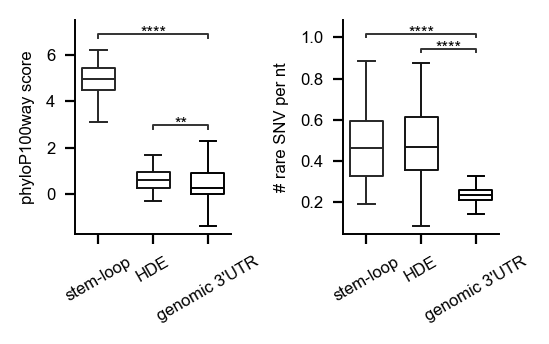

In [12]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(2.7, 1.7)
)

sns.boxplot(
    data=plot_df,
    ax=axes[0],
    x='region',
    y='phyloP',
    showfliers=False,
    hue='region',
    width=0.6,
    color='black',
    fill=False,
    linewidth=0.7
)
sns.boxplot(
    data=plot_df,
    ax=axes[1],
    x='region',
    y='density',
    showfliers=False,
    hue='region',
    width=0.6,
    color='black',
    fill=False,
    linewidth=0.7
)

axes[0].set_ylabel('phyloP100way score')
axes[1].set_ylabel('# rare SNV per nt')

pairs = [
    ('stem-loop', "genomic 3'UTR"),
    ('HDE', "genomic 3'UTR"),
]

for idx, y_col in enumerate(['phyloP', 'density']):
    annotator = Annotator(
        axes[idx],
        pairs=pairs,
        data=plot_df,
        x='region',
        y=y_col
    )
    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="inside",
        verbose=0,
        line_width=0.7,
        text_offset=-2.5,
        comparisons_correction=None,
    )
    annotator.apply_and_annotate()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('')
    # X ticks rotation
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=30,
        ha='center'
    )

plt.tight_layout()